In [169]:
import cv2 as cv
from ultralytics import YOLO
from util import *
model = YOLO("yolo26n.pt")
frame = cv.imread("D:\Computer Vision\img1.jpg")
results = model.track(frame, persist=True)
results[0].show()


0: 384x640 1 person, 8 cars, 67.6ms
Speed: 19.8ms preprocess, 67.6ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)


In [3]:
results[0].boxes

ultralytics.engine.results.Boxes object with attributes:

cls: tensor([2., 2., 2., 2., 2., 2., 2., 2., 0.])
conf: tensor([0.8916, 0.8218, 0.7362, 0.6996, 0.6193, 0.6116, 0.6100, 0.3634, 0.3575])
data: tensor([[5.6272e+02, 2.8440e+02, 6.3855e+02, 3.5597e+02, 1.0000e+00, 8.9157e-01, 2.0000e+00],
        [4.6476e+02, 2.0692e+02, 5.3036e+02, 2.5643e+02, 2.0000e+00, 8.2185e-01, 2.0000e+00],
        [4.5665e+02, 1.3976e+02, 5.0030e+02, 1.8655e+02, 3.0000e+00, 7.3619e-01, 2.0000e+00],
        [2.7726e+02, 1.2964e+02, 3.1851e+02, 1.7291e+02, 4.0000e+00, 6.9964e-01, 2.0000e+00],
        [2.6615e+02, 2.2799e+02, 3.2186e+02, 2.9134e+02, 5.0000e+00, 6.1930e-01, 2.0000e+00],
        [6.3139e-02, 1.7139e+02, 2.3055e+01, 2.4271e+02, 6.0000e+00, 6.1157e-01, 2.0000e+00],
        [1.5730e-01, 2.9880e+02, 2.8066e+01, 3.8528e+02, 7.0000e+00, 6.1004e-01, 2.0000e+00],
        [1.4449e+02, 4.0382e+02, 1.9654e+02, 4.1700e+02, 8.0000e+00, 3.6342e-01, 2.0000e+00],
        [7.3327e+01, 0.0000e+00, 8.7801e+01, 2.

In [15]:
result = results[0]
region = np.array([248, 113, 555, 313])
classId = result.boxes.id.int().cpu().numpy() if result.boxes is not None else result.obb.id.cpu().numpy()
conf = result.boxes.conf.cpu().numpy() if result.boxes is not None else result.obb.conf.cpu().numpy()
coordinates = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else result.obb.xyxyxyxy.cpu().numpy()
xyxy = result.boxes.xyxy.cpu().numpy() if result.boxes is not None else result.obb.xyxyxyxy.cpu().numpy()

labels = [f"id:{int(_id)} p:{c:.2f}" for _id, c in zip(classId, conf)]
colors = get_colors(xyxy, region)
frame = cv.imread("D:\Computer Vision\img1.jpg")
x = frame.copy()
draw_bbox(x, region, "Region", bbox_color=sv.Color.RED)
display(x, coordinates, labels, bbox_color=colors)
cv.imshow("", x)
cv.waitKey(0)   # chờ nhấn phím bất kỳ
cv.destroyAllWindows()

bboxes:  (9, 4)


In [43]:
def compute_iou(box1, box2):
    # Intersection
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    inter_w = max(0, x2 - x1)
    inter_h = max(0, y2 - y1)
    inter_area = inter_w * inter_h

    # Area of each box
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])

    # Union
    union_area = area1 + area2 - inter_area

    # IoU
    if union_area == 0:
        return 0.0
    return inter_area / union_area

In [220]:
# def get_set_overlap_ids(obj_iou):
#     set_overlap_ids = set({})
#     for i in range(obj_iou.shape[0]):
#         for j in range(obj_iou.shape[1]):
#             if obj_iou[i][j] > 0 and i != j:
#                 pair = tuple(sorted([i, j]))
#                 set_overlap_ids.add(pair)
#     print("set_overlap_ids: ", set_overlap_ids)
#     return merge_groups(set_overlap_ids)

# def merge_groups(pairs):
#     groups = []

#     for a, b in pairs:
#         merged = []
        
#         for g in groups:
#             if a in g or b in g:
#                 g.update([a, b])
#                 merged.append(g)

#         if not merged:
#             groups.append(set([a, b]))
#         else:
#             # merge overlapping groups
#             new_group = set([a, b])
#             for g in merged:
#                 new_group |= g
#                 groups.remove(g)
#             groups.append(new_group)

#     # convert sang set(tuple)
#     result = set()
#     for g in groups:
#         result.add(tuple(sorted(g)))  # sort để tránh duplicate

#     return result

In [222]:
def get_set_overlap_ids(obj_iou):
    n = obj_iou.shape[0]
    parent = list(range(n))

    def find(x):
        if parent[x] != x:
            parent[x] = find(parent[x])
        return parent[x]

    def union(x, y):
        root_x = find(x)
        root_y = find(y)
        if root_x != root_y:
            parent[root_y] = root_x

    # 🔥 chỉ duyệt nửa trên ma trận (i < j)
    for i in range(n):
        for j in range(i + 1, n):
            if obj_iou[i][j] > 0:
                union(i, j)

    # 🔥 gom group
    groups = {}
    for i in range(n):
        root = find(i)
        if root not in groups:
            groups[root] = set()
        groups[root].add(i)

    # 🔥 convert sang set(tuple)
    result = set(tuple(sorted(g)) for g in groups.values() if len(g) > 1)

    return result

In [323]:
def update_stream(frame, obj_coordinates, track_id, conf, checker_coordinate, border_coordinate):
    global is_detecting, is_first_frame, num_bboxes, last_coordinates
    error_flag = False
    if is_detecting:
        if border_coordinate is not None:
            if is_first_frame: # First frame =====FINISHED=====
                is_first_frame = False
                if all([bbox_checking(border_coordinate, obj) for obj in obj_coordinates]):
                    obj_iou = np.array([[compute_iou(obj_coordinates[i], obj_coordinates[j]) for j in range(0, len(obj_coordinates))] for i in range(len(obj_coordinates))])
                    # filter_ids = np.array([
                    #     [obj_iou[i][j] for j in range(len(obj_iou[i])) if j != i]
                    #     for i in range(len(obj_iou))
                    # ])
                    overlap_ids = np.array([
                        np.any((line > 0.0) & (line < 1.0)) # threshold overlap can be adjusted 
                        for line in obj_iou
                    ])
                    set_overlap_ids = get_set_overlap_ids(obj_iou)
                    if any(overlap_ids) == False and len(overlap_ids) == num_bboxes:
                        print("="*20)
                        print("All objects are in border region and no objects are overlaped.")
                        print("="*20)
                        last_coordinates["id"] = track_id
                        last_coordinates["coordinates"] = obj_coordinates
                    elif any(overlap_ids) == True and len(overlap_ids[overlap_ids==False]) + len(set_overlap_ids) == num_bboxes:
                        print("="*20)
                        print("All objects are in border region and some objects are overlaped.")
                        print("="*20)
                        retained_ids = np.where(overlap_ids == False) 
                        retained_ids = np.append(retained_ids, np.array(list([item[0] for item in set_overlap_ids])))
                        retained_ids = np.sort(retained_ids)
                        retained_objects = obj_coordinates[retained_ids]
                        print("retained_ids: ", retained_ids)
                        last_coordinates["id"] = track_id[retained_ids]
                        last_coordinates["coordinates"] = retained_objects
                    else:
                        error_flag = True
                        print("="*20)
                        print("Objects are obscured.")
                        print("="*20)
                else:
                    error_flag = True
                    print("="*20)
                    print("All objects is not in border region.")
                    print("="*20)
            
            else: # not first frame
                print("Not first frame")
                if all([bbox_checking(border_coordinate, obj) for obj in obj_coordinates]):
                    # retained and lost objects
                    print("All objects are in border region.")
                    lost_ids = set(last_coordinates["id"]) - set(track_id) # >= 0
                    retained_ids = set(last_coordinates["id"]) & set(track_id)
                    lost_ids = np.array(list(lost_ids)) # track id has lost 
                    retained_id_indices = np.where(np.isin(track_id, np.array(list(retained_ids))))[0] # retained id indices
                    print("lost_ids: ", lost_ids)
                    if lost_ids.size == 0 and len(track_id) == num_bboxes: # case 1: good
                        # pass
                        print("="*20)
                        print("No objects lost. CASE 1")
                        print("="*20)
                        # last_coordinates["id"] = track_id
                        # last_coordinates["coordinates"] = obj_coordinates
                    elif lost_ids.size == 0 and len(track_id) > num_bboxes: # case 5:excess objects: good
                         print("="*20)
                         print("No objects lost but some new objects are detected. CASE 5")
                         print("="*20)
                    else: # lost_ids > 0
                        obj_iou = np.array([[compute_iou(obj_coordinates[i], obj_coordinates[j]) for j in range(0, len(obj_coordinates))] for i in range(len(obj_coordinates))])
                        overlap_ids = np.array([
                            np.any((line > 0.0) & (line < 1.0)) # threshold overlap can be adjusted 
                            for line in obj_iou
                        ])
                        set_overlap_ids = get_set_overlap_ids(obj_iou) # >= 0
                        print("set_overlap_ids: ", set_overlap_ids) 
                        if len(set_overlap_ids) == 0: # don't have overlap
                            if len(track_id) == num_bboxes: # case 6: lost 1 ID 
                                print("="*20)
                                print("All objects are in border region and no objects are overlaped and one ID has been lost. CASE 6")
                                print("="*20)
                            elif len(track_id) < num_bboxes: # CASE 3:
                                print("="*20)
                                print("All objects are in border region and no objects are overlaped and some ID has been lost. CASE 3")
                                print("="*20)
                        else:  # set_overlap_ids > 0
                            print("="*20)
                            print("Objects are obscured. CASE 2, 4")
                            print("="*20)
                        
        
                else: # not all objects are in border region
                    pass
            
    else: # not detecting, do nothing
        pass 




Not first frame
All objects are in border region.
lost_ids:  [5]
set_overlap_ids:  set()
All objects are in border region and no objects are overlaped and one ID has been lost. CASE 6
bboxes:  (5, 4)


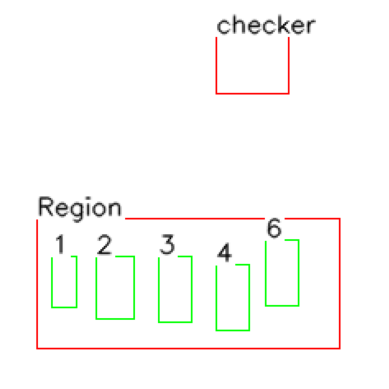

In [331]:
is_first_frame = False
conf = np.array([0.9, 0.85, 0.8, 0.75, 0.7, 0.65, 0.6, 0.55]) # overlap
checker_coordinate = np.array([125, 16, 169, 51])  # Màu đỏ
border_coordinates = np.array([16, 127, 200, 206])  
obj_coordinates_second = np.array([
    [25, 150, 40, 181],
    [52, 150, 75, 188],
    [90, 150, 110, 190],
    [125, 155, 145, 195],
    [155, 140, 175, 180],
    # [165, 146, 190, 190], # overlap 5,6
    # [118, 138, 130, 175], # overlap 4, 7
    # [180, 170, 195, 195]# overlap 5,6, 8

    # [118, 78, 148, 108 ] # out region
])
track_id_second = np.array([1, 2, 3,4, 6])
conf = np.array([0.9, 0.85, 0.8, 0.75, 0.7]) 

update_stream(frame, obj_coordinates_second, track_id_second, conf, checker_coordinate, border_coordinates) 

colors = get_colors(obj_coordinates_second, border_coordinates)
labels = [f"{i}" for i in track_id_second]
annotated_frame = frame.copy()
draw_bbox(annotated_frame, checker_coordinate, "checker", bbox_color=sv.Color.RED)
draw_bbox(annotated_frame, border_coordinates, "Region", bbox_color=sv.Color.RED)
display(annotated_frame, obj_coordinates_second, labels, bbox_color=colors)
plt.imshow(cv.cvtColor(annotated_frame, cv.COLOR_BGR2RGB))  # Chuyển đổi màu sắc từ BGR sang RGB
plt.axis('off')  # Tắt hiển thị trục
plt.show()


In [ ]:
import matplotlib.pyplot as plt
img_path = "D:\Computer Vision\white.png"
frame = cv.imread(img_path)

# =======GLOBAL VARIABLES========
is_first_frame = False
is_detecting = True
num_bboxes = 5
last_coordinates = {}

border_coordinates = np.array([16, 127, 200, 206])  
obj_coordinates = np.array([
    [25, 150, 40, 181],
    [52, 150, 75, 188],
    [90, 150, 110, 190],
    [125, 155, 145, 195],
    [155, 140, 175, 180],
    # [165, 146, 190, 190], # overlap 5,6
    # [118, 138, 130, 175], # overlap 4, 7
    # [180, 170, 195, 195]# overlap 5,6, 8

    # [118, 78, 148, 108 ] # out region
])
track_id = np.array([1, 2, 3, 4, 5])
# track_id = np.array([1, 2, 3, 4, 5, 6, 7, 8]) # overlap
# conf = np.array([0.9, 0.85, 0.8, 0.75, 0.7])

last_coordinates

{'id': array([1, 2, 3, 4, 5]),
 'coordinates': array([[ 25, 150,  40, 181],
        [ 52, 150,  75, 188],
        [ 90, 150, 110, 190],
        [125, 155, 145, 195],
        [165, 146, 190, 190]])}